In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier , LogisticRegression
from sklearn.pipeline import Pipeline , make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import log_loss , ConfusionMatrixDisplay , classification_report

In [ ]:

from sklearn.datasets import fetch_openml
x_pd , y_pd = fetch_openml('mnist_784' , version=1 , return_X_y=True)
x = x_pd.to_numpy()
y = y_pd.to_numpy()

scaler = MinMaxScaler()
X = scaler.fit_transform(x)

target_names = np.unique(y)

x_train, x_test, y_train, y_test = X[ :60000], X[60000 : ] , y[ : 60000], y[ 60000 : ]

y_train_0 = np.zeros(len(y_train))
y_test_0 = np.zeros(len(y_test))

index_0 = np.where(y_train=='0')
y_train_0[index_0] = 1

index_0 = np.where(y_test=='0')
y_test_0[index_0] = 1

In [16]:
sgd_clf = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0,
    max_iter=1,
    eta0=0.01,
    warm_start=True,
    learning_rate="constant",
    random_state=1729
)

pipe_sgd_ovr = Pipeline([
    ("min_max_scaler" , MinMaxScaler()),
    ("SGD_Classifier" , sgd_clf)
])

In [18]:
Loss = []
iterations = 100
for i in range(iterations):
    pipe_sgd_ovr.fit(x_train , y_train)
    y_hat_test = pipe_sgd_ovr.predict_proba(x_test)
    score = log_loss(y_test,y_hat_test)
    Loss.append(score)

c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consid

### Understanding SGD Custom Training Loop & Log Loss

Ye code block actual mein ek bohot hi smart aur advanced technique hai jisko Machine Learning mein **"Learning Curve Track Karna"** bolte hain. Chalo tumhare teeno sawalon ko ek-ek karke break down karte hain.

#### 1. Log Loss Kyu Calculate Kar Rahe Hain?
Machine Learning model ko train karte waqt hume uski "Galti" (Error) mapni hoti hai taaki wo sudhar sake. Regression (Continuous numbers) mein hum Mean Squared Error (MSE) nikalte thay. Lekin Classification (0 ya 1) mein MSE achhe se kaam nahi karta kyunki math ajeeb ho jati hai.

Classification ke liye sabse best error nikalne ka tarika hai **Log Loss** (jisko Cross-Entropy Loss bhi kehte hain). Ye model ki galti nikalne ka standard mathematical formula hai. Hamara goal is loop ke through yahi dekhna hai ki jaise-jaise iterations badh rahi hain, kya ye "Galti" (Loss) kam ho rahi hai ya nahi.

#### 2. Log Loss Ko `predict_proba` (Probability) Kyu Chahiye?
Log loss ka main logic sirf sahi ya galat batana nahi hai, balki **Confidence (Overconfidence) par penalty lagana hai.**

Socho actual answer $1$ (Class 1) hai.
* **Scenario A:** Model ne kaha: "Mujhe 51% lagta hai ki ye 1 hai." Answer sahi hai, par model sure nahi tha.
* **Scenario B:** Model ne kaha: "Mujhe 99.9% lagta hai ki ye 0 hai." Answer galat hai, aur model **bohot overconfident** tha.

Agar tum normally `.predict()` use karte, toh wo model sirf $0$ ya $1$ output karta. Usme "confidence" kitna hai, wo math ko pata nahi chalta. Log loss ka formula probabilities ke log par based hota hai:
$$L = - \frac{1}{N} \sum [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$$
*(Jahan $\hat{y}$ probability hai).* Agar model galat answer par 99% confident hota hai, toh Log Loss formula usko ek bohot badi (infinity ke paas) penalty deta hai. Isliye, log loss calculate karne ke liye `predict_proba` dena **compulsory** hota hai taaki equation ko exact percentages mil sakein.

#### 3. Hum Ye Manual For-Loop (Iterations) Kyu Chala Rahe Hain?
Ye sabse main sawal hai! Normally `SGDClassifier` khud hi andar ek loop chalata hai. Tum simply usko `max_iter=100` de dete aur `.fit()` likh dete, toh wo apna kaam kar leta. 

Lekin, agar wo chup-chap andar hi 100 baar chal gaya, toh tumhe kaise pata chalega ki 10th step par error kitna tha? Ya 50th step par error kitna tha? Tumhe graph (curve) banane ke liye har ek step ka loss chahiye.

Is trick ko dhyan se dekho:
1.  **`max_iter=1`**: Tumne model ko bola "Bhai, tu sirf 1 step aage badhna (sirf ek gradient update karna) aur ruk jana."
2.  **`warm_start=True`**: Tumne bola "Agli baar jab main `.fit()` call karu, toh purane weights se hi aage badhna, zero se shuru mat karna."
3.  **The Loop:** * Tum `.fit()` call karte ho. Model 1 step leta hai.
    * Tum naye weights par loss nikalte ho aur list (`Loss.append()`) mein daal lete ho.
    * Loop ghumta hai. Model wahi se aage 1 step aur leta hai.

Is loop ke khatam hone ke baad tumhare paas 100 numbers ki ek list hogi. Agar tum isko Matplotlib se plot karoge, toh tumhe ek dum mast neeche jaati hui curve dikhegi (Gradient descent in action!), jo prove karegi ki tumhara model sach mein har step ke sath kuch na kuch seekh raha tha.

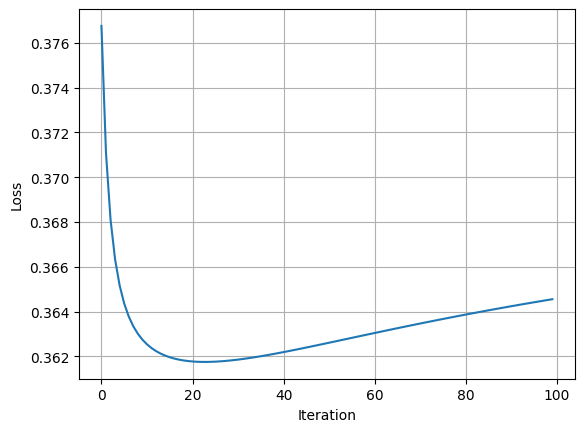

In [20]:
plt.figure()
plt.plot(np.arange(iterations), Loss)
plt.grid(True)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

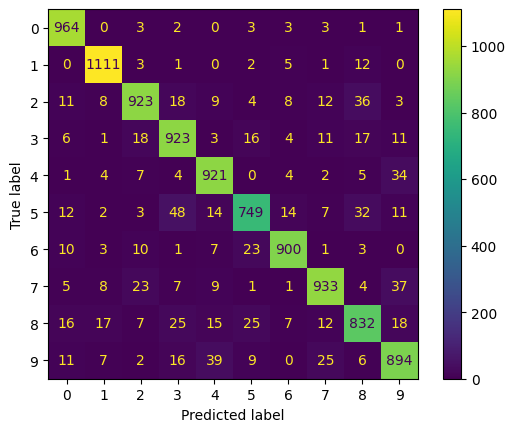

In [28]:
y_hat_test = pipe_sgd_ovr.predict(x_test)
cm_matrix = ConfusionMatrixDisplay.from_predictions(y_test , y_hat_test , values_format='.5g')
plt.show()

In [36]:
print(classification_report(y_test , y_hat_test))


              precision    recall  f1-score   support

           0       0.93      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.92      0.89      0.91      1032
           3       0.88      0.91      0.90      1010
           4       0.91      0.94      0.92       982
           5       0.90      0.84      0.87       892
           6       0.95      0.94      0.95       958
           7       0.93      0.91      0.92      1028
           8       0.88      0.85      0.87       974
           9       0.89      0.89      0.89      1009

    accuracy                           0.92     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.92      0.91     10000



#### MultiClass LogisticRegression Using Solver

In [49]:
pipe_sgd_ovr = make_pipeline(
    MinMaxScaler(),
    LogisticRegression(
        random_state=1729,
        solver="lbfgs",
        C=np.inf
    )
)
pipe_sgd_ovr.fit(x_train , y_train)

c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('minmaxscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l

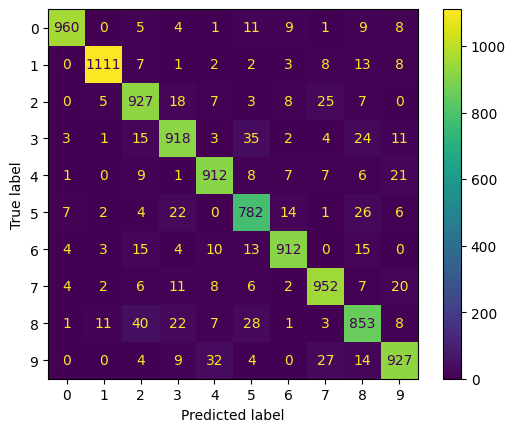

In [52]:
y_hat = pipe_sgd_ovr.predict(x_test)
cm_matrix = ConfusionMatrixDisplay.from_predictions(y_hat,y_test , values_format=".5g")

In [53]:
print(classification_report(y_hat , y_test))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1008
           1       0.98      0.96      0.97      1155
           2       0.90      0.93      0.91      1000
           3       0.91      0.90      0.91      1016
           4       0.93      0.94      0.93       972
           5       0.88      0.91      0.89       864
           6       0.95      0.93      0.94       976
           7       0.93      0.94      0.93      1018
           8       0.88      0.88      0.88       974
           9       0.92      0.91      0.92      1017

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000

